# 🧠 What is an Artificial Neural Network (ANN)?

An **Artificial Neural Network (ANN)** is a type of **machine learning model** inspired by the structure and function of the human brain.  

It consists of layers of interconnected nodes (neurons) that can learn complex patterns from data.

---

## 🔥 Key Components of ANN

1. **Input Layer**  
   - Takes in the features of the dataset (e.g., TF-IDF vectors or pixel values).
2. **Hidden Layers**  
   - Multiple layers where computations happen.
   - Each neuron applies a weight, bias, and activation function.
3. **Output Layer**  
   - Produces the final prediction (e.g., class label probabilities).

---

## 📦 How ANN Works (Step by Step)

1. **Input Features** → Passed to the network
2. **Weighted Sum** → Each neuron calculates a weighted sum of inputs
3. **Activation Function** → Decides whether the neuron should activate
4. **Output** → Passed to the next layer or returned as the prediction
5. **Training** → Weights and biases are adjusted using backpropagation and optimization (like gradient descent)

---

## 🏆 Difference Between ANN and Traditional Machine Learning

| Feature                          | Traditional ML                | Artificial Neural Network (ANN)   |
|-----------------------------------|--------------------------------|-------------------------------------|
| **Feature Extraction**            | Manual (e.g., TF-IDF, BoW)     | Can learn features automatically   |
| **Layers**                        | Single layer (shallow)         | Multiple layers (deep learning)    |
| **Complex Patterns**              | Limited                        | Handles highly non-linear patterns |
| **Training Data Requirement**     | Works well with small datasets | Needs large datasets to perform well|
| **Example Algorithms**            | Logistic Regression, SVM, RF   | Dense ANN, CNN, RNN, Transformers  |

---

## 💡 Why Use ANN?

✅ Can handle large and complex datasets  
✅ Learns intricate patterns that traditional ML might miss  
✅ Especially useful in:
- Text classification (NLP)
- Image recognition
- Speech processing

---

## 📌 Summary

| ANN = Layers of neurons that learn patterns from raw or numeric data |
|----------------------------------------------------------------------|
| Unlike traditional ML, ANN learns both features and classification. |

---


# 🧠 Artificial Neural Networks (ANN) for Text Classification using TF-IDF

In this notebook, we will:
- Create a **dummy dataset** (Terrorism vs Non-Terrorism)
- Preprocess text data using **TF-IDF**
- Train a **simple ANN** to classify text
- Evaluate the model and display predictions

---

## 📌 1. Introduction

Text classification is a common task in Natural Language Processing (NLP). We can use **Artificial Neural Networks (ANNs)** to learn patterns from text data.

Here we will use:
- **TF-IDF (Term Frequency-Inverse Document Frequency)** to convert text into numeric vectors
- A simple ANN built with TensorFlow/Keras

The goal is to classify texts as:
- `Terrorism`
- `Non-Terrorism`

---

## 📝 2. Dataset Preparation
We create a small dummy dataset with 50 text samples, labeled as `"Terrorism"` or `"Non-Terrorism"`.


In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# 1️⃣ Create Dummy Dataset
data = {
    "Text": [
        "Bomb blast in the city kills dozens",
        "Terrorist group claims responsibility for the attack",
        "Police found explosives in the abandoned car",
        "Peace talks between countries resume this week",
        "Charity raises funds for flood victims",
        "Military operation against militants continues",
        "Sports event gathers thousands of fans",
        "Government condemns the terror attack strongly",
        "New airport inaugurated in the capital",
        "Gunmen attack security forces in border area",
        "Students celebrate independence day with parade",
        "Suicide bomber detonates in crowded market",
        "Anti-terrorism unit arrests three suspects",
        "Healthcare workers vaccinated rural population",
        "Explosion near embassy kills five civilians",
        "Film festival showcases award-winning movies",
        "Airstrike targets terrorist hideouts in mountains",
        "Local community plants trees in public park",
        "Militant leader captured by special forces",
        "Economic growth hits record high this quarter",
        "Hostage situation ends with police intervention",
        "Education reforms announced by ministry",
        "Terror cell dismantled by intelligence agencies",
        "Cyclone warning issued for coastal regions",
        "Attackers open fire at security checkpoint",
        "Blood donation camp organized by students",
        "Rocket fired at military base from unknown location",
        "New hospital opens for rural health services",
        "Explosion damages government building downtown",
        "Football team wins national championship",
        "IED blast injures two soldiers on patrol",
        "Festival attracts international tourists",
        "Security forces raid terrorist safe house",
        "Heavy rainfall causes flooding in villages",
        "Bomb defused by bomb disposal squad",
        "Technology fair showcases innovation",
        "Terror suspects caught at international airport",
        "Volunteers clean up city streets after event",
        "Grenade attack reported in urban market",
        "Cultural exchange program launched",
        "Insurgents attack convoy near border",
        "Farmers protest against new agricultural laws",
        "Ambush on army convoy results in casualties",
        "Children participate in art competition",
        "Gunfire heard in remote tribal area",
        "Job fair provides employment opportunities",
        "Improvised explosive device found on roadside",
        "Health officials combat dengue outbreak",
        "Security alert issued after intelligence reports",
        "Peace conference aims to end conflict"
    ],
    "Label": [
        "Terrorism", "Terrorism", "Terrorism", "Non-Terrorism", "Non-Terrorism",
        "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism",
        "Non-Terrorism", "Terrorism", "Terrorism", "Non-Terrorism", "Terrorism",
        "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism",
        "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism",
        "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism",
        "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism",
        "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism",
        "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism",
        "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism"
    ]
}

df = pd.DataFrame(data)
pd.set_option('display.max_colwidth', None)
print("📄 Full Dataset:")
# Display first 5 rows
print(df.shape)  # Should be (50, 2)
df

📄 Full Dataset:
(50, 2)


,Text,Label
0,Bomb blast in the city kills dozens,Terrorism
1,Terrorist group claims responsibility for the attack,Terrorism
2,Police found explosives in the abandoned car,Terrorism
3,Peace talks between countries resume this week,Non-Terrorism
4,Charity raises funds for flood victims,Non-Terrorism
5,Military operation against militants continues,Terrorism
6,Sports event gathers thousands of fans,Non-Terrorism
7,Government condemns the terror attack strongly,Terrorism
8,New airport inaugurated in the capital,Non-Terrorism
9,Gunmen attack security forces in border area,Terrorism


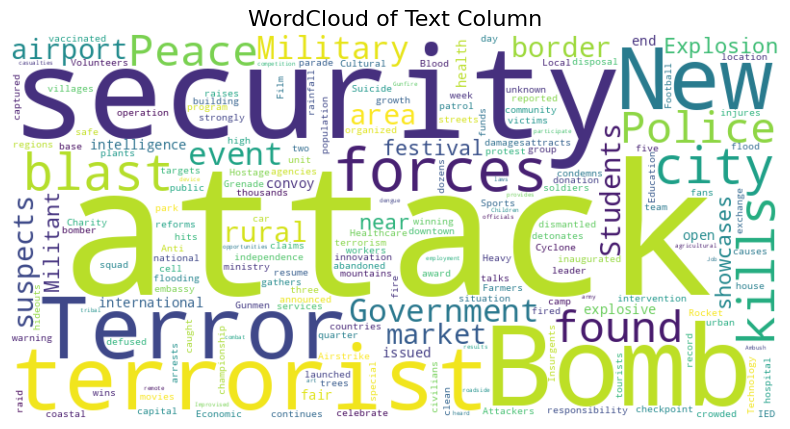

In [2]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# Combine all text from the 'Text' column
text_data = ' '.join(df['Text'].dropna().astype(str))

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # No axes
plt.title("WordCloud of Text Column", fontsize=16)
plt.show()

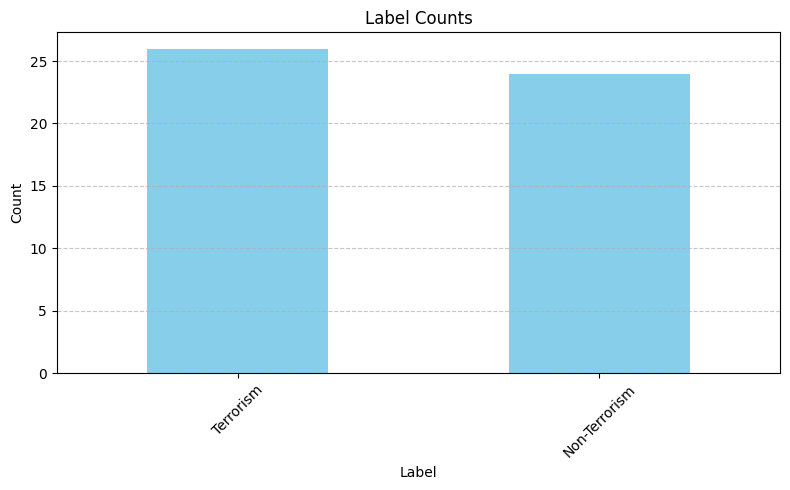

In [3]:
import matplotlib.pyplot as plt

# Count the occurrences of each label
label_counts = df['Label'].value_counts()

# Plot the bar graph
plt.figure(figsize=(8, 5))
label_counts.plot(kind='bar', color='skyblue')
plt.title('Label Counts')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


---

## 📌 3. Preprocessing

### 🔤 3.1 Encode Labels
We use **LabelEncoder** to convert categorical labels (`Terrorism`, `Non-Terrorism`) into numeric (1, 0).


In [4]:
# Encode Labels
encoder = LabelEncoder()
df["Encoded_Label"] = encoder.fit_transform(df["Label"])
print("\n🔤 Encoded Labels (Terrorism=1, Non-Terrorism=0):")
df


🔤 Encoded Labels (Terrorism=1, Non-Terrorism=0):


,Text,Label,Encoded_Label
0,Bomb blast in the city kills dozens,Terrorism,1
1,Terrorist group claims responsibility for the attack,Terrorism,1
2,Police found explosives in the abandoned car,Terrorism,1
3,Peace talks between countries resume this week,Non-Terrorism,0
4,Charity raises funds for flood victims,Non-Terrorism,0
5,Military operation against militants continues,Terrorism,1
6,Sports event gathers thousands of fans,Non-Terrorism,0
7,Government condemns the terror attack strongly,Terrorism,1
8,New airport inaugurated in the capital,Non-Terrorism,0
9,Gunmen attack security forces in border area,Terrorism,1


### 📦 3.2 Convert Text to Numeric Vectors (TF-IDF)

TF-IDF transforms each text into a vector where:
- Each dimension corresponds to a word in the vocabulary
- Values represent the importance of the word in the document


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
#  TF-IDF Vectorization
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(df["Text"]).toarray()

print("\n📦 TF-IDF Matrix Shape:", X_tfidf.shape)
print("\n📜 TF-IDF Feature Names:")
print(vectorizer.get_feature_names_out())


📦 TF-IDF Matrix Shape: (50, 225)

📜 TF-IDF Feature Names:
['abandoned' 'after' 'against' 'agencies' 'agricultural' 'aims' 'airport'
 'airstrike' 'alert' 'ambush' 'announced' 'anti' 'area' 'army' 'arrests'
 'art' 'at' 'attack' 'attackers' 'attracts' 'award' 'base' 'between'
 'blast' 'blood' 'bomb' 'bomber' 'border' 'building' 'by' 'camp' 'capital'
 'captured' 'car' 'casualties' 'caught' 'causes' 'celebrate' 'cell'
 'championship' 'charity' 'checkpoint' 'children' 'city' 'civilians'
 'claims' 'clean' 'coastal' 'combat' 'community' 'competition' 'condemns'
 'conference' 'conflict' 'continues' 'convoy' 'countries' 'crowded'
 'cultural' 'cyclone' 'damages' 'day' 'defused' 'dengue' 'detonates'
 'device' 'dismantled' 'disposal' 'donation' 'downtown' 'dozens'
 'economic' 'education' 'embassy' 'employment' 'end' 'ends' 'event'
 'exchange' 'explosion' 'explosive' 'explosives' 'fair' 'fans' 'farmers'
 'festival' 'film' 'fire' 'fired' 'five' 'flood' 'flooding' 'football'
 'for' 'forces' 'found' '

In [6]:
print("\n📊 TF-IDF Values (All rows):")
tfidf_df = pd.DataFrame(X_tfidf, columns=vectorizer.get_feature_names_out())
# Show all columns (no truncation)
pd.set_option('display.max_columns', None)
tfidf_df


📊 TF-IDF Values (All rows):


,abandoned,after,against,agencies,agricultural,aims,airport,airstrike,alert,ambush,announced,anti,area,army,arrests,art,at,attack,attackers,attracts,award,base,between,blast,blood,bomb,bomber,border,building,by,camp,capital,captured,car,casualties,caught,causes,celebrate,cell,championship,charity,checkpoint,children,city,civilians,claims,clean,coastal,combat,community,competition,condemns,conference,conflict,continues,convoy,countries,crowded,cultural,cyclone,damages,day,defused,dengue,detonates,device,dismantled,disposal,donation,downtown,dozens,economic,education,embassy,employment,end,ends,event,exchange,explosion,explosive,explosives,fair,fans,farmers,festival,film,fire,fired,five,flood,flooding,football,for,forces,found,from,funds,gathers,government,grenade,group,growth,gunfire,gunmen,health,healthcare,heard,heavy,hideouts,high,hits,hospital,hostage,house,ied,improvised,in,inaugurated,independence,injures,innovation,insurgents,intelligence,international,intervention,issued,job,kills,launched,laws,leader,local,location,market,militant,militants,military,ministry,mountains,movies,national,near,new,of,officials,on,open,opens,operation,opportunities,organized,outbreak,parade,park,participate,patrol,peace,plants,police,population,program,protest,provides,public,quarter,raid,rainfall,raises,record,reforms,regions,remote,reported,reports,responsibility,results,resume,roadside,rocket,rural,safe,security,services,showcases,situation,soldiers,special,sports,squad,streets,strongly,students,suicide,suspects,talks,targets,team,technology,terror,terrorism,terrorist,the,this,thousands,three,to,tourists,trees,tribal,two,unit,unknown,up,urban,vaccinated,victims,villages,volunteers,warning,week,winning,wins,with,workers
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.399201,0.000000,0.399201,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.399201,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.441427,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.246493,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.399201,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.00000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.327015,0.000000,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.318451,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0000

## 📌 4. Train/Test Split
We split data into:
- **Training set (80%)**
- **Testing set (20%)**


In [7]:
# Features and Labels
X = X_tfidf
y = df["Encoded_Label"]

# 4️⃣ Split Data
X_train, X_test, y_train, y_test, text_train, text_test = train_test_split(
    X, y, df["Text"], test_size=0.2, random_state=42)

print("\n📏 Shape After Split:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


📏 Shape After Split:
X_train: (40, 225) X_test: (10, 225)
y_train: (40,) y_test: (10,)


## 📌 5. Build ANN Model

The ANN has:
- Input layer (size = TF-IDF feature vector)
- 1 Hidden layer (ReLU activation)
- Output layer (Sigmoid for binary classification)


## 🏗️ Build ANN Model – Parameters Explained

We use Keras’ Sequential API to build a simple ANN for binary classification. Below is the explanation of each parameter.

---

## 🏗️ Build ANN Model – Parameters Explained

---

### 🔹 **Dense Layer Parameters**
Each `Dense()` layer adds a **fully connected layer** to the ANN.  

---

#### 📝 Parameters:
- **units (16, 8, 1)**  
  - Number of neurons in each layer.  
  - **First hidden layer →** 16 neurons  
  - **Second hidden layer →** 8 neurons  
  - **Output layer →** 1 neuron (for binary classification)

- **input_dim=X_train.shape[1]**  
  - Specifies the number of input features (columns) in `X_train`.  
  - Tells the model how many inputs to expect.

- **activation='relu'**  
  - Activation function for hidden layers.  
  - ReLU (Rectified Linear Unit) introduces non-linearity by replacing negative values with 0.

- **activation='sigmoid'**  
  - Activation function for the output layer.  
  - Sigmoid maps output to a range between 0 and 1.  
  - Used in binary classification to produce probabilities.

---

### 🔹 **model.compile() Parameters**
The `compile()` method configures the ANN for training.

---

#### 📝 Parameters:
- **optimizer='adam'**  
  - Optimization algorithm that adjusts weights and biases to minimize loss.  
  - Adam is fast and widely used because it combines the advantages of RMSProp and SGD with momentum.

- **loss='binary_crossentropy'**  
  - Loss function for binary classification problems.  
  - Measures the difference between predicted probabilities and actual labels.

- **metrics=['accuracy']**  
  - Evaluation metric to monitor during training and testing.  
  - Shows the percentage of correct predictions.

---

### 🔹 **model.summary()**
Prints a detailed summary of the ANN architecture.  

Displays:
- Each layer type
- Number of neurons
- Total trainable parameters (weights and biases)

---

### ✅ Quick Recap
This ANN consists of:
- **Input layer →** size based on number of features
- **2 Hidden layers →** ReLU activations
- **Output layer →** Sigmoid activation for binary classification
- Compiled with **Adam optimizer** and **binary_crossentropy** loss



In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#  Build ANN Model
# Parameters = (Number of inputs × Number of neurons) + Number of biases
model = Sequential([
    Dense(16, input_dim=X_train.shape[1], activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

#  Compile ANN Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │         3,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,761 (14.69 KB)

 Trainable params: 3,761 (14.69 KB)

 Non-trainable params: 0 (0.00 B)

## 📌 6. Train Model

## 📦 Parameter Explanations for model.fit()

---

### 🔹 **X_train**
The **feature matrix (input data)** used to train the model.  
Each row represents one training example, and each column represents a feature.

---

### 🔹 **y_train**
The **target labels** corresponding to each row in `X_train`.  
It tells the model what the correct output should be for each input.

---

### 🔹 **epochs=20**
- Number of times the entire training dataset is passed through the ANN.
- Each epoch means **one complete forward and backward pass** of all training examples.
- 📌 **Tip:** 
  - More epochs → Model learns better (up to a point).
  - Too many epochs → Risk of **overfitting** (model memorizes training data).

---

### 🔹 **batch_size=4**
- Number of samples the model processes **before updating weights**.
- Instead of updating weights after seeing the full dataset (like in batch gradient descent), the model updates them after seeing `batch_size` samples.

#### ✅ Effects of Batch Size:
- **Smaller batch sizes:**
  - Require more updates per epoch (slower training).
  - Can help the model generalize better due to more noisy updates.
- **Larger batch sizes:**
  - Faster training per epoch.
  - But might generalize worse on some datasets.

---

### 🔹 **validation_split=0.2**
- Reserves **20% of the training data for validation**.
- The model trains on the remaining **80%** and evaluates its performance on the validation set after each epoch.

#### 📊 Why use validation_split?
- Helps monitor:
  - **Validation loss**
  - **Validation accuracy**
- Checks if the model is **overfitting** (when validation loss increases while training loss decreases).

---

### ✅ Summary
These parameters control **how the model trains**, **how often it updates weights**, and **how we monitor its performance during training**.


In [9]:

# 6️⃣ Train Model
history = model.fit(X_train, y_train, epochs=20, batch_size=4, validation_split=0.2)

# Total Data = 50
# Train = 40 (32 Training (batch size = 4 => total batchs = 8) and 8 for validation)
# Test = 10


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5122 - loss: 0.6964 - val_accuracy: 0.5000 - val_loss: 0.6989
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5769 - loss: 0.6900 - val_accuracy: 0.5000 - val_loss: 0.6983
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6694 - loss: 0.6892 - val_accuracy: 0.5000 - val_loss: 0.6968
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7034 - loss: 0.6849 - val_accuracy: 0.3750 - val_loss: 0.6964
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8116 - loss: 0.6803 - val_accuracy: 0.3750 - val_loss: 0.6955
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6866 - loss: 0.6839 - val_accuracy: 0.3750 - val_loss: 0.6951
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8612 - loss: 0.6778 - val_accuracy: 0.3750 - val_loss: 0.6951
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7866 - loss: 0.6712 - val_accuracy: 0.3750 - val_loss: 0.6946


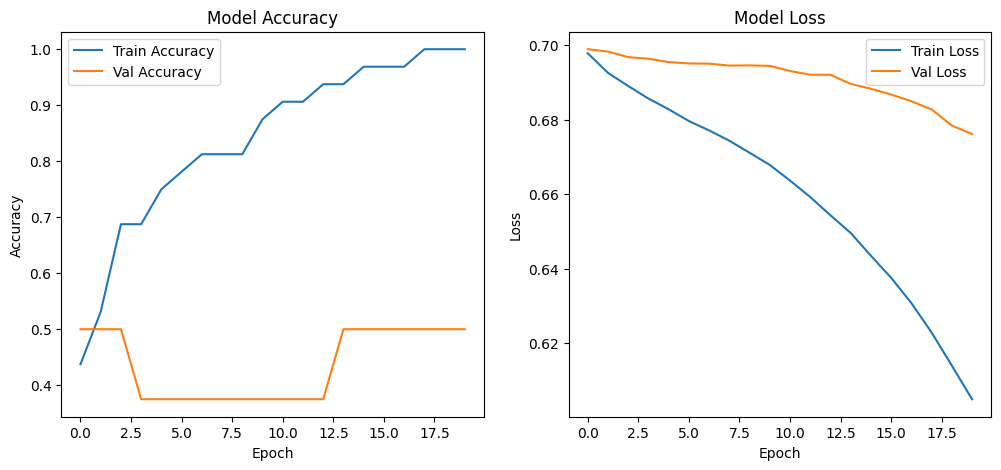

In [10]:
import matplotlib.pyplot as plt

# Plot accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


## 📌 7. Evaluate Model
We test the model on unseen data.


In [11]:
# 7️⃣ Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {accuracy:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.6000 - loss: 0.6878

✅ Test Accuracy: 0.60


## 📌 8. Make Predictions
Show predicted labels alongside actual text and labels.

### 🤔 Why model.predict(X_test) > 0.5?

The ANN outputs probabilities because the last layer uses a **Sigmoid activation**:  
This gives values between **0 and 1**, showing the probability of class 1 (Terrorism).  
Example:
- `0.48 → 48% chance Terrorism`
- `0.56 → 56% chance Terrorism`

---

### 🎯 Why threshold 0.5?
We use `> 0.5` to convert probabilities into class labels:
- Probability > 0.5 → Predict **Terrorism (1)**
- Probability ≤ 0.5 → Predict **Non-Terrorism (0)**

This is the **default threshold**.

---

### 📌 Can we change it?
✅ Yes! Adjust threshold based on needs:  
| Threshold | Effect                                     |
|-----------|---------------------------------------------|
| Lower (e.g., 0.3) | More sensitive (higher recall)      |
| Higher (e.g., 0.7) | More conservative (higher precision)|

Example:
```python
threshold = 0.3
y_pred = (model.predict(X_test) > threshold).astype(int)




In [12]:
pred = model.predict(X_test)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


array([[0.48440355],
       [0.5347097 ],
       [0.5030295 ],
       [0.5290361 ],
       [0.51531696],
       [0.49366495],
       [0.5235922 ],
       [0.49811757],
       [0.5432257 ],
       [0.46925783]], dtype=float32)

In [16]:
[0.49394968], 0 
[0.48841247], 0
[0.56172264], 1
[0.56753314], 1
[0.47769862], 0
[0.5087798 ], 1
[0.5443133 ], 1
[0.48206797], 0
[0.5808109 ], 1
[0.5294379 ], 1


# Predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32").flatten()

# Map encoded labels back to original
y_test_labels = encoder.inverse_transform(y_test)
y_pred_labels = encoder.inverse_transform(y_pred)

# Show Actual Text, Actual Label, Predicted Label
results_df = pd.DataFrame({
    "Text": text_test.values,
    "Actual Label": y_test_labels,
    "Predicted Label": y_pred_labels
}).reset_index(drop=True)

print("\n📌 Results (Text | Actual Label | Predicted Label):")
results_df

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

📌 Results (Text | Actual Label | Predicted Label):


,Text,Actual Label,Predicted Label
0,Healthcare workers vaccinated rural population,Non-Terrorism,Non-Terrorism
1,Cultural exchange program launched,Non-Terrorism,Terrorism
2,IED blast injures two soldiers on patrol,Terrorism,Terrorism
3,Job fair provides employment opportunities,Non-Terrorism,Terrorism
4,Local community plants trees in public park,Non-Terrorism,Terrorism
5,Security alert issued after intelligence reports,Terrorism,Non-Terrorism
6,Rocket fired at military base from unknown location,Terrorism,Terrorism
7,Blood donation camp organized by students,Non-Terrorism,Non-Terrorism
8,Security forces raid terrorist safe house,Terrorism,Terrorism
9,Economic growth hits record high this quarter,Non-Terrorism,Non-Terrorism


In [17]:
from sklearn.metrics import classification_report, confusion_matrix
# 📊 Classification Report
print("\n📑 Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))


📑 Classification Report:
               precision    recall  f1-score   support

Non-Terrorism       0.75      0.50      0.60         6
    Terrorism       0.50      0.75      0.60         4

     accuracy                           0.60        10
    macro avg       0.62      0.62      0.60        10
 weighted avg       0.65      0.60      0.60        10




 Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


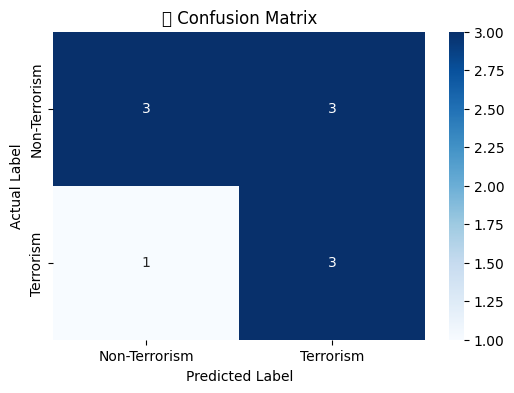

In [18]:
import seaborn as sns
# 📊 Confusion Matrix
print("\n Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

# 🎨 Confusion Matrix (Visual)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("🔵 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()